# ☔ Umbrella Prediction using Logistic Regression

## Problem Description

In this project, I build a simple logistic regression model to predict the need of an umbrella.
The goal is to understand the fundamentals of supervised learning (logistic regression) by implementing the model step by step and observing how the algorithm learns from data. Since this dataset has two features with very different value ranges (percentage, degrees Celsius), this notebook also introduces feature scaling.

## Dataset
For this experiment, I use a dataset with two features:

**Feature(input):**
- Humidity (%)
- Temperature (Celsius)

**Target (Prediction):**
- Umbrella needed (1 = Yes / 0 = No)

The dataset represents how humidity and temperature interact to determine if it is going to rain, requiring an umbrella.

## Objective

The objective is to implement logistic regression from scratch, including:
- model prediction
- cost function
- gradient descent optimization
- feature scaling

After training, the model should be able to predict if an umbrella is needed and output a clear binary classification (Yes/No) based on a 0.5 threshold, visualized by a decision boundary line. 

In [458]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

## 1. Sigmoid Function
The sigmoid function maps any real-valued number into a probability between 0 and 1:
$$g(z) = \frac{1}{1 + e^{-z}}$$

In [459]:
def sigmoid(z):
    
    """Compute the sigmoid of z."""
    
    return 1 / (1 + np.exp(-z))

## 2. Generate Data:

In [460]:
np.random.seed(42) # for reproducibility

number_of_samples = 200
humidity = np.random.uniform(60, 90, number_of_samples)       # humidity in %
temperature = np.random.uniform(-2, 30, number_of_samples)    # temperature °C

bias = -(0.15 * 75 - 0.1 * 14)  # = -9.85
z = 0.15 * humidity - 0.1 * temperature + bias
probability = sigmoid(z)

umbrella_needed = (np.random.uniform(0, 1, number_of_samples) < probability).astype(int)
umbrella = np.where(umbrella_needed == 1, "Yes ☔", "No ☀️")

print(f"Number of training examples: {number_of_samples}")
display(pd.DataFrame({"humidity": humidity, "temperature": temperature, "umbrella": umbrella}).head())

Number of training examples: 200


,humidity,temperature,umbrella
0,71.236204,18.545013,Yes ☔
1,88.521429,0.692479,Yes ☔
2,81.959818,3.172119,Yes ☔
3,77.959755,26.753734,No ☀️
4,64.680559,17.405730,No ☀️


## 3. Visualize Data:

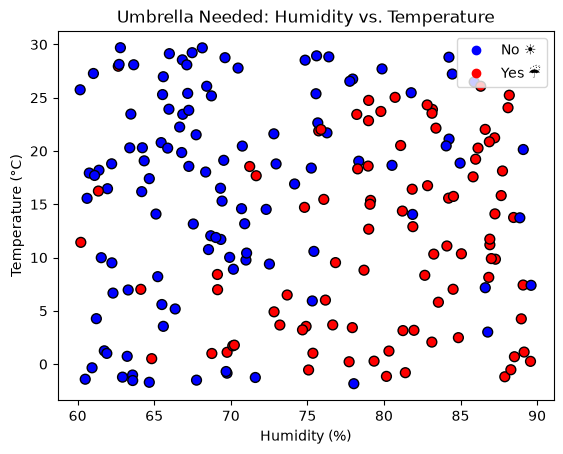

In [461]:
scatter = plt.scatter(humidity, temperature, c=umbrella_needed, cmap="bwr", edgecolor="k", s=50)

plt.xlabel("Humidity (%)")
plt.ylabel("Temperature (°C)")
plt.title("Umbrella Needed: Humidity vs. Temperature")

plt.legend(handles=scatter.legend_elements()[0], labels=["No ☀️", "Yes ☔"])

plt.show()

## 4. Feature Scaling (Z-score Normalization)

All features will have mean a 0. and a standard deviation of 1 after z-score normalization.

$$
\begin{aligned} 
x^{(i)}_j = \dfrac{x^{(i)}_j - \mu_j}{\sigma_j}
\end{aligned} 
$$  

where $j$ selects a feature or a column in the $\mathbf{X}$ matrix. $\mu_j$ is the mean of all the values for feature (j) and $\sigma_j$ is the standard deviation of feature (j). 

$$ 
\begin{aligned} 
\mu_j &= \frac{1}{m} \sum_{i=0}^{m-1} x^{(i)}_j \\
\sigma^2_j &= \frac{1}{m} \sum_{i=0}^{m-1} (x^{(i)}_j - \mu_j)^2 \\
\sigma_j &= \sqrt{\sigma^2_j}
\end{aligned} 
$$


In [462]:
X_train = np.column_stack((humidity, temperature))

X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

X_scaled = (X_train - X_mean) / X_std

print(f"X_mean: {X_mean}")
print(f"X_std: {X_std}")
print(f"X_scaled[:5]:\n{X_scaled[:5]}")

X_mean: [74.520187   14.14000434]
X_std: [8.82459836 9.35256867]
X_scaled[:5]:
[[-0.37213971  0.47099449]
 [ 1.58661523 -1.43784301]
 [ 0.84305607 -1.17271371]
 [ 0.38977043  1.34869148]
 [-1.11502273  0.34917953]]


## 5. Cost Function (Log Loss / Logistic Loss)
For logistic regression, we use the binary cross-entropy loss function:
$$J(\vec{w},b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(f_{\vec{w},b}(\vec{x}^{(i)})) + (1 - y^{(i)}) \log(1 - f_{\vec{w},b}(\vec{x}^{(i)})) \right]$$

where the model prediction is:
$$f_{\vec{w},b}(\vec{x}) = g(\vec{w} \cdot \vec{x} + b)$$


In [463]:
def compute_cost(X, y, w, b):

    """Compute cost for logistic regression.

    Args:
        X: input feature values
        y: target values
        w: model weight vector (one entry per feature)
        b: model bias

    Returns:
        total_cost: the computed cost J(w,b)
    """
    
    m = X.shape[0] # number of training examples
    cost = 0

    for i in range(m):
        z_i = np.dot(w, X[i]) + b
        f_wb_i = sigmoid(z_i)

        loss = -(y[i] * np.log(f_wb_i) + (1 - y[i]) * np.log(1 - f_wb_i))
        cost += loss

    total_cost = cost / m

    return total_cost

## 6. Gradient Function
The mathematical equations for the gradients look visually identical to linear regression, 
but remember that $f_{\vec{w},b}(\vec{x})$ now contains the non-linear sigmoid function.

$$\frac{\partial J(\vec{w},b)}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} (f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)}) x_j^{(i)}$$
$$\frac{\partial J(\vec{w},b)}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})$$


In [464]:
def compute_gradient(X, y, w, b):
    
    """Compute the gradient for logistic regression."""

    m, n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.0

    for i in range(m):
        z_i = np.dot(w, X[i]) + b
        f_wb_i = sigmoid(z_i)

        err_i = f_wb_i - y[i]
        
        for j in range(n):
            dj_dw[j] += err_i * X[i, j]
        
        dj_db += err_i

    dj_dw = dj_dw / m
    dj_db = dj_db / m
    
    return dj_dw, dj_db

## 7. Gradient Descent

In [465]:
def gradient_descent(X, y, w_inital, b_inital, alpha, number_of_iterations, cost_function, gradient_function):
    """Perform gradient descent to fit w and b for logistic regression.

    Args:
        X: input feature values
        y: target values
        w_inital: initial value of w
        b_inital: initial value of b
        alpha: learning rate
        number_of_iterations: number of gradient descent steps to run
        cost_function: function to compute the cost J(w,b)
        gradient_function: function to compute the gradients dj_dw, dj_db

    Returns:
        w: final learned weight
        b: final learned bias
        J_history: list of cost values at each iteration
    """

    J_history = []
    w = w_inital
    b = b_inital

    for i in range(number_of_iterations):

        dj_dw, dj_db = gradient_function(X, y, w, b)
                                 
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # Save data at each iteration to print gradient descent process
        if i < 100000: # prevent ressource exhaustion, not more than 100000 iterations
            J_history.append(cost_function(X, y, w, b))
        # Print data every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(number_of_iterations/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:,.4f}  ",
                f"dj_dw: {dj_dw}, dj_db: {dj_db:,.4f}  ",
                f"w: {w}, b: {b:,.4f}")

    return w, b, J_history 

## 8. Run Gradient Descent

In [466]:
# initialize parameters
w_inital = np.zeros(2)
b_inital = 0

# some gradient descent settings
iterations = 100
tmp_alpha = 0.75
y_train = umbrella_needed

# run gradient descent
w_final, b_final, J_hist = gradient_descent(
    X_scaled, 
    y_train, 
    w_inital, 
    b_inital, 
    tmp_alpha, 
    iterations, 
    compute_cost, 
    compute_gradient
)

print(f"(w,b) found by gradient descent: ({w_final},{b_final})")

Iteration    0: Cost 0.6267   dj_dw: [-0.28248375  0.12493913], dj_db: 0.0500   w: [ 0.21186281 -0.09370435], b: -0.0375
Iteration   10: Cost 0.4802   dj_dw: [-0.05851483  0.02870102], dj_db: 0.0117   w: [ 1.11118254 -0.49664601], b: -0.2030
Iteration   20: Cost 0.4678   dj_dw: [-0.02240688  0.01301372], dj_db: 0.0051   w: [ 1.3730582  -0.63692187], b: -0.2588
Iteration   30: Cost 0.4654   dj_dw: [-0.01043815  0.00664542], dj_db: 0.0025   w: [ 1.48498902 -0.70529619], b: -0.2851
Iteration   40: Cost 0.4648   dj_dw: [-0.00528663  0.00352149], dj_db: 0.0013   w: [ 1.53961399 -0.74096115], b: -0.2986
Iteration   50: Cost 0.4646   dj_dw: [-0.0027874   0.00189772], dj_db: 0.0007   w: [ 1.56790458 -0.7600379 ], b: -0.3058
Iteration   60: Cost 0.4646   dj_dw: [-0.00149987  0.00103194], dj_db: 0.0004   w: [ 1.58299017 -0.77036931], b: -0.3097
Iteration   70: Cost 0.4646   dj_dw: [-0.00081565  0.00056404], dj_db: 0.0002   w: [ 1.59115528 -0.77600313], b: -0.3118
Iteration   80: Cost 0.4646   dj

## 9. Visualize the result (Decision Boundary)

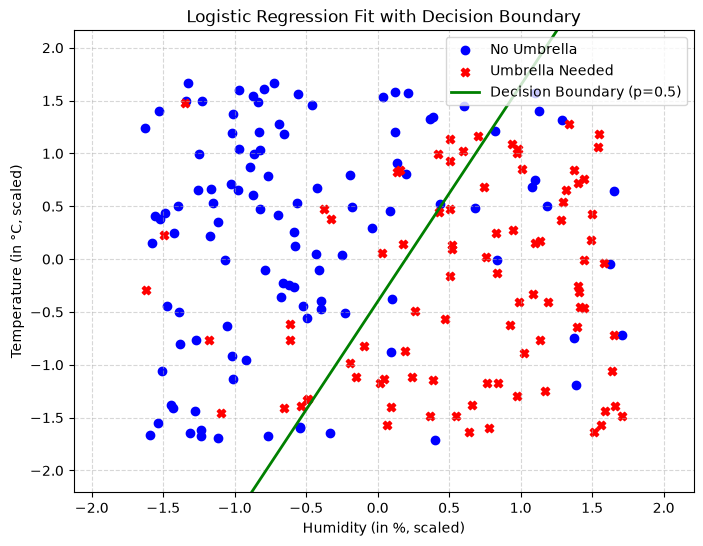

In [ ]:
# The boundary is where w0*x0 + w1*x1 + b = 0. 
# Solving for x1 (Temperature): x1 = (-b - w0*x0) / w1

plt.figure(figsize=(8, 6))

# Plot scaled data points
plt.scatter(X_scaled[y_train == 0, 0], X_scaled[y_train == 0, 1], color="blue", marker="o", label="No Umbrella")
plt.scatter(X_scaled[y_train == 1, 0], X_scaled[y_train == 1, 1], color="red", marker="X", label="Umbrella Needed")

# Calculate the decision boundary line over the scaled x0 axis
x0_boundary = np.array([X_scaled[:, 0].min(), X_scaled[:, 0].max()])
x1_boundary = (-b_final - w_final[0] * x0_boundary) / w_final[1]

# Plot line
plt.plot(x0_boundary, x1_boundary, color="green", linewidth=2, label="Decision Boundary (p=0.5)")

plt.xlabel("Humidity (Scaled)")
plt.ylabel("Temperature Scaled)")
plt.title("Logistic Regression Fit with Decision Boundary")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5)
plt.ylim(X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5)
plt.show()


## 10. Make a Prediction

In [468]:
# We must scale new inputs using the exact same mean and std dev from the training set!
def predict_umbrella(new_humidity, new_temperature):
    # 1. Scale input
    scaled_hum = (new_humidity - X_mean[0]) / X_std[0]
    scaled_temp = (new_temperature - X_mean[1]) / X_std[1]
    
    # 2. Compute probability
    z = w_final[0] * scaled_hum + w_final[1] * scaled_temp + b_final
    prob = sigmoid(z)
    
    # 3. Classify
    decision = "Yes ☔" if prob >= 0.5 else "No ☀️"
    print(f"Inputs: Humidity {new_humidity}%, Temp {new_temperature}°C -> Rain Probability: {prob*100:.1f}% -> Need Umbrella? {decision}")

# Test scenarios
predict_umbrella(95, 12)  # High humidity, cool -> High probability
predict_umbrella(40, 25)  # Low humidity, warm -> Low probability

print("\nEdge Case:")
predict_umbrella(80, 22)  # Close to the decision boundary line


Inputs: Humidity 95%, Temp 12°C -> Rain Probability: 97.3% -> Need Umbrella? Yes ☔
Inputs: Humidity 40%, Temp 25°C -> Rain Probability: 0.1% -> Need Umbrella? No ☀️

Edge Case:
Inputs: Humidity 80%, Temp 22°C -> Rain Probability: 50.6% -> Need Umbrella? Yes ☔


## 11. Reflection

The decision boundary occasionally misclassifies points near the 50/50 probability
range — expected, since labels were generated with randomness rather than a hard
threshold, giving the model genuinely ambiguous cases to learn from.
